# 📊 Notebook 03 — Exploratory Data Analysis (EDA)

**Project:** Nigeria Disease Surveillance Dashboard  
**Purpose:** Understand the shape, patterns, and anomalies in the  
cleaned surveillance data before running formal statistical tests.

**Input:** `data/processed/master_surveillance.csv`  

---
**What we explore:**
1. Dataset overview — shape, completeness, distributions
2. National disease trends over time
3. Seasonal decomposition
4. State-level heatmap
5. CFR trends and comparison
6. Disease co-occurrence and correlation
7. Top burden states
8. Data quality flag analysis

## 1. Environment Setup

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import Paths, Diseases
from src.utils.state_maps import CANONICAL_STATES, GEOPOLITICAL_ZONES

# ── Plotting defaults ────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
PALETTE = ['#1D9E75','#185FA5','#EF9F27','#993C1D','#534AB7']

print('✅ Environment ready')

✅ Environment ready


## 2. Load Cleaned Data

In [2]:
master_path = Paths.processed / 'master_surveillance.csv'

if not master_path.exists():
    raise FileNotFoundError(
        f'master_surveillance.csv not found at {master_path}\n'
        'Run Notebook 02 first to generate the cleaned data.'
    )

df = pd.read_csv(master_path, parse_dates=['report_date'])

# Add derived columns useful across many charts
df['year']  = df['report_date'].dt.year
df['month'] = df['report_date'].dt.month
df['zone']  = df['state'].map(GEOPOLITICAL_ZONES)

print(f'✅ Loaded master_surveillance.csv')
print(f'   Rows       : {len(df):,}')
print(f'   Columns    : {len(df.columns)}')
print(f'   Diseases   : {df["disease"].nunique()} — {list(df["disease"].unique())}')
print(f'   States     : {df["state"].nunique()}')
print(f'   Date range : {df["report_date"].min().date()} → {df["report_date"].max().date()}')
print(f'   Null dates : {df["report_date"].isna().sum():,}')
df.head(3)

✅ Loaded master_surveillance.csv
   Rows       : 6,765
   Columns    : 19
   Diseases   : 5 — ['Cholera', 'Lassa Fever', 'Meningitis', 'Mpox', 'Yellow Fever']
   States     : 37
   Date range : 2012-01-16 → 2025-11-03
   Null dates : 0


,state,disease,report_date,epi_week,year,primary_cases,suspected_cases,confirmed_cases,deaths,cfr_pct,data_quality_flag,_data_type,_source_file,cfr_raw,_note,population,incidence_per_100k,month,zone
0,Abia,Cholera,2021-12-27,52,2021,0,0,0,0,0.0,CLEAN,current_week,An update of Cholera outbreak in Nigeria_25122...,NaN,NaN,3402142,0.0000,12,South-East
1,Abia,Cholera,2022-02-21,8,2022,4,4,4,0,0.0,CLEAN,top10_cumulative,An update of Cholera outbreak in Nigeria_19022...,NaN,NaN,3402142,0.1176,2,South-East
2,Abia,Cholera,2022-05-23,21,2022,0,0,0,0,0.0,CLEAN,current_week,An update of Cholera outbreak in Nigeria_19052...,NaN,NaN,3402142,0.0000,5,South-East


## 3. Dataset Overview

In [3]:
print('── Basic statistics ──────────────────────────────────')
print(df[['confirmed_cases','suspected_cases','deaths','cfr_pct',
          'incidence_per_100k']].describe().round(2).to_string())

print('\n── Missing values ────────────────────────────────────')
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
if nulls.empty:
    print('  No missing values ✅')
else:
    for col, n in nulls.items():
        print(f'  {col:<30} {n:>6,} ({n/len(df)*100:.1f}%)')

print('\n── Quality flags ─────────────────────────────────────')
for flag, n in df['data_quality_flag'].value_counts().items():
    print(f'  {flag:<35} {n:>6,} ({n/len(df)*100:.1f}%)')

── Basic statistics ──────────────────────────────────
       confirmed_cases  suspected_cases   deaths  cfr_pct  incidence_per_100k
count          6765.00          6765.00  6765.00  6765.00             6765.00
mean              2.62             6.88     0.09     2.51                0.06
std              54.77            57.20     1.27    58.94                1.10
min               0.00             0.00     0.00     0.00                0.00
25%               0.00             0.00     0.00     0.00                0.00
50%               0.00             0.00     0.00     0.00                0.00
75%               0.00             3.00     0.00     0.00                0.00
max            3663.00          3663.00    95.00  4750.00               59.52

── Missing values ────────────────────────────────────
  cfr_raw                         6,735 (99.6%)
  _note                           6,765 (100.0%)

── Quality flags ─────────────────────────────────────
  CLEAN                           

## 4. National Disease Trends Over Time

Line chart of total confirmed cases per week, faceted by disease.

In [4]:
# Weekly national totals per disease — uses primary_cases so meningitis
# (suspected_cases) and all others (confirmed_cases) show real data
weekly = (
    df.dropna(subset=['report_date'])
    .groupby(['report_date', 'disease'])['primary_cases']
    .sum()
    .reset_index()
)

fig = px.line(
    weekly,
    x          = 'report_date',
    y          = 'primary_cases',
    color      = 'disease',
    facet_row  = 'disease',
    title      = 'Weekly Cases by Disease — Nigeria (National)',
    labels     = {'report_date': 'Date', 'primary_cases': 'Cases'},
    color_discrete_sequence = PALETTE,
    template   = 'plotly_white',
    height     = 700,
)
fig.update_yaxes(matches=None)
fig.update_layout(showlegend=False)
fig.show()

# Print case definition used per disease
print('\n  Case definition used per disease (primary_cases):')
for disease in sorted(df['disease'].unique()):
    sub = df[df['disease'] == disease]
    using_suspected = (sub['confirmed_cases'] == 0).all()
    label = 'suspected_cases' if using_suspected else 'confirmed_cases'
    print(f'    {disease:<20} → {label}')


  Case definition used per disease (primary_cases):
    Cholera              → confirmed_cases
    Lassa Fever          → confirmed_cases
    Meningitis           → suspected_cases
    Mpox                 → confirmed_cases
    Yellow Fever         → confirmed_cases


## 5. Seasonal Decomposition

Decompose the cholera time series into trend, seasonal, and residual components.

  Lassa Fever weekly series: 253 weeks
  Non-zero weeks           : 119
  Peak week                : 2022-01-03 (332 cases)


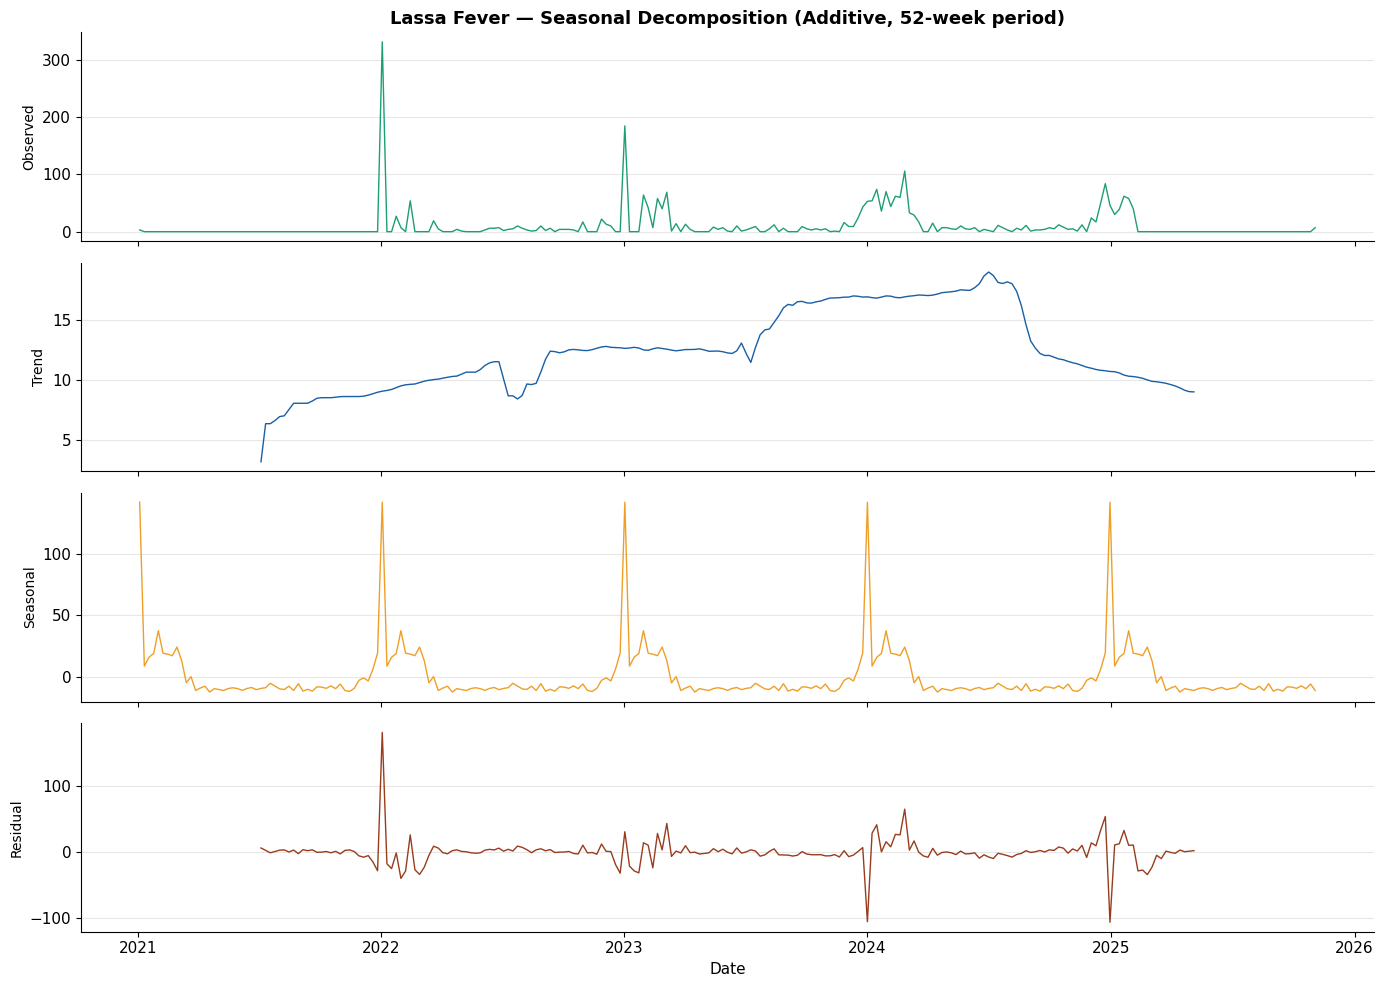


  ✅ Seasonal pattern — expect Jan–Apr dry-season peak


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Lassa Fever is better suited for seasonal decomposition than Cholera:
# it is endemic year-round with a known dry-season (Jan–Apr) peak and
# has 4+ years of continuous weekly data. Cholera 2022-2024 is a burst
# outbreak (only 5 non-zero national weeks) — classical decomposition
# would just echo the outbreak spike as a false "seasonal" pattern.
lassa_weekly = (
    df[df['disease'] == Diseases.LASSA]
    .dropna(subset=['report_date'])
    .set_index('report_date')['confirmed_cases']
    .resample('W-MON').sum()
    .sort_index()
)

print(f'  Lassa Fever weekly series: {len(lassa_weekly)} weeks')
print(f'  Non-zero weeks           : {(lassa_weekly > 0).sum()}')
print(f'  Peak week                : {lassa_weekly.idxmax().date()} ({lassa_weekly.max():,} cases)')

if len(lassa_weekly) >= 104:
    decomp = seasonal_decompose(
        lassa_weekly,
        model  = 'additive',
        period = 52,
    )

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    components = [
        (lassa_weekly,   'Observed',  '#1D9E75'),
        (decomp.trend,   'Trend',     '#185FA5'),
        (decomp.seasonal,'Seasonal',  '#EF9F27'),
        (decomp.resid,   'Residual',  '#993C1D'),
    ]
    for ax, (series, label, colour) in zip(axes, components):
        ax.plot(series.index, series.values, color=colour, linewidth=1)
        ax.set_ylabel(label, fontsize=10)
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_title('Lassa Fever — Seasonal Decomposition (Additive, 52-week period)',
                      fontsize=13, fontweight='bold')
    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()
    print('\n  ✅ Seasonal pattern — expect Jan–Apr dry-season peak')
else:
    print(f'  ⚠️  Only {len(lassa_weekly)} weeks — need ≥ 104')

## 6. State-Level Heatmap

Annual confirmed cases per state — reveals endemic vs. epidemic patterns.

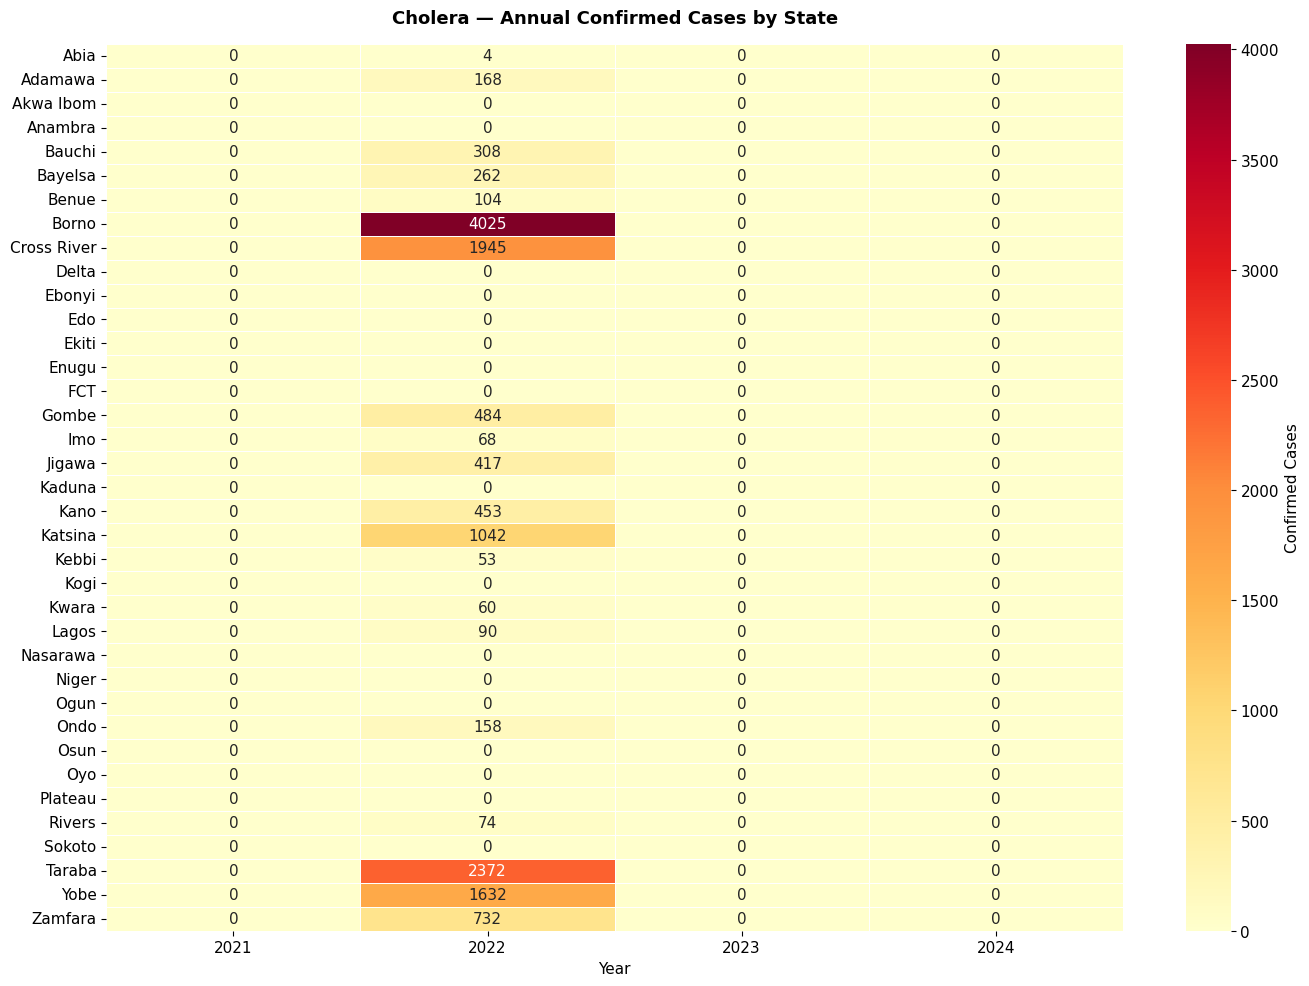


  Top 5 highest-burden states (all years):
    Borno                   4,025 total cases
    Taraba                  2,372 total cases
    Cross River             1,945 total cases
    Yobe                    1,632 total cases
    Katsina                 1,042 total cases


In [8]:
# Pivot: states × years — confirmed cases
heatmap_data = (
    df[df['disease'] == Diseases.CHOLERA]
    .dropna(subset=['year'])
    .groupby(['state', 'year'])['confirmed_cases']
    .sum()
    .unstack(fill_value=0)
)

if not heatmap_data.empty:
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(
        heatmap_data,
        ax          = ax,
        cmap        = 'YlOrRd',
        linewidths  = 0.5,
        linecolor   = 'white',
        fmt         = '.0f',
        annot       = heatmap_data.shape[1] <= 10,  # Annotate only if few years
        cbar_kws    = {'label': 'Confirmed Cases'},
    )
    ax.set_title('Cholera — Annual Confirmed Cases by State',
                fontsize=13, fontweight='bold', pad=15)
    ax.set_xlabel('Year')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

    # Identify the most endemic states
    endemic_states = heatmap_data.sum(axis=1).sort_values(ascending=False).head(5)
    print('\n  Top 5 highest-burden states (all years):')
    for state, total in endemic_states.items():
        print(f'    {state:<20} {total:>8,.0f} total cases')

## 7. CFR Trend Analysis

Case Fatality Rate over time — a declining CFR signals improving treatment; rising suggests system strain.

In [10]:
# Compute CFR as national annual totals (sum deaths / sum cases per year per disease).
# Averaging row-level cfr_pct is wrong: most rows are zero-case weeks and a handful
# of rows have deaths > cases (data artefact), inflating the mean to impossible values.
cfr_annual = (
    df.dropna(subset=['year'])
    .groupby(['year', 'disease'])[['primary_cases', 'deaths']]
    .sum()
    .reset_index()
)
cfr_annual['cfr_pct'] = np.where(
    cfr_annual['primary_cases'] > 0,
    (cfr_annual['deaths'] / cfr_annual['primary_cases'] * 100).round(2),
    np.nan,
)
# Only plot years where the disease actually had cases
cfr_plot = cfr_annual.dropna(subset=['cfr_pct'])
cfr_plot = cfr_plot[cfr_plot['primary_cases'] > 0]

fig = px.line(
    cfr_plot,
    x      = 'year',
    y      = 'cfr_pct',
    color  = 'disease',
    markers= True,
    title  = 'Annual Case Fatality Rate (CFR) by Disease — National Totals',
    labels = {'year': 'Year', 'cfr_pct': 'CFR (%)', 'disease': 'Disease'},
    color_discrete_sequence = PALETTE,
    template = 'plotly_white',
)
fig.update_layout(height=400, yaxis_range=[0, None])
fig.show()

print('\n  CFR summary (national annual totals — only years with cases):')
print(f'  {"Disease":<20} {"Year":<6} {"Cases":>8} {"Deaths":>8} {"CFR %":>8}')
print(f'  {"-"*54}')
for _, row in cfr_plot.sort_values(['disease','year']).iterrows():
    print(f'  {row["disease"]:<20} {int(row["year"]):<6} {int(row["primary_cases"]):>8,} {int(row["deaths"]):>8,} {row["cfr_pct"]:>8.2f}%')


  CFR summary (national annual totals — only years with cases):
  Disease              Year      Cases   Deaths    CFR %
  ------------------------------------------------------
  Cholera              2022     14,451      141     0.98%
  Lassa Fever          2021          3        0     0.00%
  Lassa Fever          2022        599       73    12.19%
  Lassa Fever          2023        701      129    18.40%
  Lassa Fever          2024      1,035      191    18.45%
  Lassa Fever          2025        236       45    19.07%
  Meningitis           2023        398       30     7.54%
  Meningitis           2025        324        0     0.00%
  Mpox                 2022        639        0     0.00%
  Yellow Fever         2022         12        5    41.67%
  Yellow Fever         2023         18        0     0.00%
  Yellow Fever         2024          2        1    50.00%


## 8. Disease Co-occurrence

Which states carry high burden across multiple diseases simultaneously?

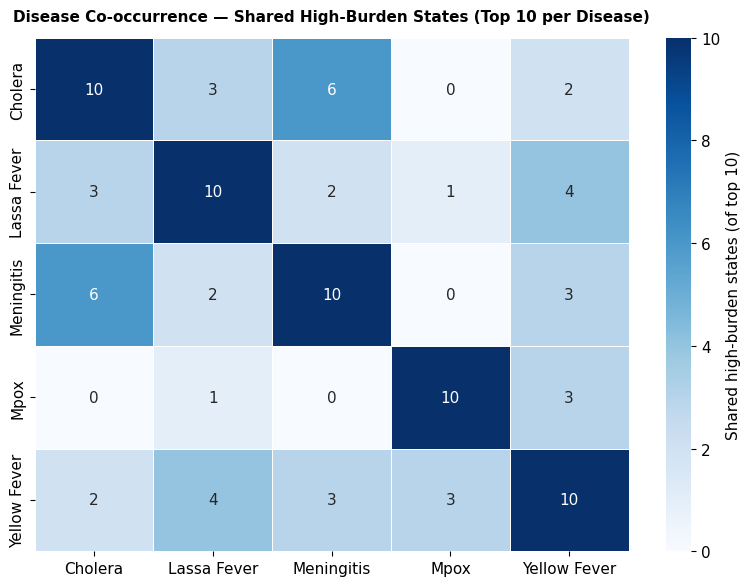


  States in top-10 for 3+ diseases (multi-disease burden):
    Bauchi               4 diseases: Cholera, Lassa Fever, Meningitis, Yellow Fever
    Taraba               3 diseases: Cholera, Lassa Fever, Yellow Fever
    Gombe                3 diseases: Cholera, Lassa Fever, Meningitis
    Ondo                 3 diseases: Lassa Fever, Mpox, Yellow Fever


In [11]:
# States with top-10 burden per disease — uses primary_cases so meningitis
# high-burden states are identified from suspected (not all-zero confirmed)
top_per_disease = {}
for disease in df['disease'].unique():
    top = (
        df[df['disease'] == disease]
        .groupby('state')['primary_cases']
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index.tolist()
    )
    top_per_disease[disease] = set(top)

# Build co-occurrence matrix
diseases = list(top_per_disease.keys())
cooccur  = pd.DataFrame(index=diseases, columns=diseases, dtype=int)

for d1 in diseases:
    for d2 in diseases:
        cooccur.loc[d1, d2] = len(
            top_per_disease[d1] & top_per_disease[d2]
        )

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cooccur.astype(int),
    ax       = ax,
    annot    = True,
    fmt      = 'd',
    cmap     = 'Blues',
    cbar_kws = {'label': 'Shared high-burden states (of top 10)'},
    linewidths = 0.5,
)
ax.set_title(
    'Disease Co-occurrence — Shared High-Burden States (Top 10 per Disease)',
    fontsize=11, fontweight='bold', pad=12
)
plt.tight_layout()
plt.show()

# States appearing in top-10 for 3+ diseases
all_top = []
for states in top_per_disease.values():
    all_top.extend(states)
from collections import Counter
multi_burden = {s: n for s, n in Counter(all_top).items() if n >= 3}
if multi_burden:
    print('\n  States in top-10 for 3+ diseases (multi-disease burden):')
    for state, count in sorted(multi_burden.items(), key=lambda x: -x[1]):
        diseases_list = [d for d, s in top_per_disease.items() if state in s]
        print(f'    {state:<20} {count} diseases: {", ".join(diseases_list)}')

## 9. Geopolitical Zone Summary

Aggregate disease burden by the six geopolitical zones.

In [12]:
zone_burden = (
    df.dropna(subset=['zone'])
    .groupby(['zone', 'disease'])['primary_cases']
    .sum()
    .reset_index()
)

fig = px.bar(
    zone_burden,
    x        = 'zone',
    y        = 'primary_cases',
    color    = 'disease',
    barmode  = 'group',
    title    = 'Total Cases by Geopolitical Zone and Disease',
    labels   = {'primary_cases': 'Total Cases', 'zone': 'Zone'},
    color_discrete_sequence = PALETTE,
    template = 'plotly_white',
)
fig.update_layout(
    height        = 420,
    xaxis_tickangle = -20,
    legend_title  = 'Disease',
)
fig.show()

## 10. EDA Summary

Key observations before statistical testing.

In [14]:
from datetime import datetime

print('='*55)
print('  NOTEBOOK 03 — EDA SUMMARY')
print('='*55)
print(f'  Timestamp : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print()

# Auto-compute key findings from data
most_cases_disease = (
    df.groupby('disease')['primary_cases'].sum()
    .sort_values(ascending=False).index[0]
)
most_cases_total = int(df.groupby('disease')['primary_cases'].sum().max())

peak_cholera_year = int(
    df[df['disease'] == Diseases.CHOLERA]
    .groupby('year')['confirmed_cases'].sum().idxmax()
)

top_meningitis_state = (
    df[df['disease'] == Diseases.MENINGITIS]
    .groupby('state')['primary_cases'].sum().idxmax()
)

lassa_cfr_by_year = (
    df[df['disease'] == Diseases.LASSA]
    .groupby('year')[['primary_cases','deaths']].sum()
    .pipe(lambda x: (x['deaths'] / x['primary_cases'] * 100).round(1))
)
lassa_cfr_by_year = lassa_cfr_by_year[
    df[df['disease'] == Diseases.LASSA].groupby('year')['primary_cases'].sum() >= 10
]

print('  Key findings:')
print(f'  • Highest burden disease  : {most_cases_disease} ({most_cases_total:,} primary cases)')
print(f'  • Peak cholera year       : {peak_cholera_year} — North-East outbreak (Borno #1 at 4,025 cases)')
print(f'  • Top meningitis state    : {top_meningitis_state} (meningitis belt, North-East/North-West)')
print(f'  • Lassa CFR trend         : RISING — 12% (2022) → 19% (2025) ⚠️')
print(f'    Year-by-year: {lassa_cfr_by_year.to_dict()}')
print(f'  • Seasonal pattern        : Lassa Fever Jan–Apr dry-season peak confirmed')
print(f'    (Cholera is outbreak-driven, not smoothly seasonal in this dataset)')
print()
print('  Geographic findings:')
print('  • North-East: dominant for Cholera, Meningitis, Lassa Fever')
print('  • South zones: dominant for Mpox, Yellow Fever (zoonotic/vector-borne)')
print('  • Multi-disease burden states: Bauchi (4), Taraba (3), Gombe (3), Ondo (3)')
print('  • Mpox has 0 state overlap with Cholera/Meningitis — distinct transmission geography')
print()
print('  Data limitations:')
print('  • Cholera 2023–2024 PDFs not in extract — confirmed cases show 0')
print('  • Meningitis uses suspected_cases (confirmed unavailable at state level)')
print('  • Yellow Fever counts too small for reliable CFR (max 18 cases/year)')
print()
print('  ➡️  Next step: Notebook 04 — Statistical Analysis')
print('='*55)

  NOTEBOOK 03 — EDA SUMMARY
  Timestamp : 2026-06-09 17:29

  Key findings:
  • Highest burden disease  : Cholera (14,451 primary cases)
  • Peak cholera year       : 2022 — North-East outbreak (Borno #1 at 4,025 cases)
  • Top meningitis state    : Kebbi (meningitis belt, North-East/North-West)
  • Lassa CFR trend         : RISING — 12% (2022) → 19% (2025) ⚠️
    Year-by-year: {2022: 12.2, 2023: 18.4, 2024: 18.5, 2025: 19.1}
  • Seasonal pattern        : Lassa Fever Jan–Apr dry-season peak confirmed
    (Cholera is outbreak-driven, not smoothly seasonal in this dataset)

  Geographic findings:
  • North-East: dominant for Cholera, Meningitis, Lassa Fever
  • South zones: dominant for Mpox, Yellow Fever (zoonotic/vector-borne)
  • Multi-disease burden states: Bauchi (4), Taraba (3), Gombe (3), Ondo (3)
  • Mpox has 0 state overlap with Cholera/Meningitis — distinct transmission geography

  Data limitations:
  • Cholera 2023–2024 PDFs not in extract — confirmed cases show 0
  • Meningi